# Project 18, часть 2: диагностика, исправленный hybrid, анализ ошибок по контексту генома

Запускай сверху вниз, как первый ноутбук. Данные и сборки из части 1 берутся с Google Drive (`MyDrive/project18/p18_out`), ничего заново скачивать не нужно.

**Что делает этот ноутбук:**
1. Диагностирует странную сборку `long_30x` (длина 9,4 Мб при геноме 4,6 Мб).
2. Заменяет упавший Unicycler на два рабочих варианта: SPAdes hybrid и Flye + полировка короткими ридами (Polypolish).
3. Повторяет сборку long-only с другим seed (реплика), чтобы увидеть разброс.
4. Находит участки референса, которые каждая сборка не покрыла, и смотрит, чем они являются (rRNA, IS-элементы, GC).
5. Считает долю indel-ошибок в гомополимерах.
6. Пересчитывает QUAST по всем сборкам, строит графики и таблицу стоимости.

**Время:** ~1,5–2 часа. В конце последняя клетка (12) создаёт `results_bundle_part2.zip`.

## 1. conda (если runtime сброшен; если нет, ничего не произойдёт)

In [ ]:
import os, subprocess
if not os.path.exists('/usr/local/bin/conda'):
    subprocess.run(['pip', 'install', '-q', 'condacolab'], check=True)
    import condacolab
    condacolab.install()   # runtime restarts; continue from the next cell
else:
    print('conda already installed -> go to the next cell')

conda already installed -> go to the next cell


## 2. Настройки и функции (те же, что в части 1)

In [ ]:
import os, subprocess, time, json, re, glob, shutil
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

DRIVE = Path('/content/drive/MyDrive/project18')
LOCAL = Path('/content/p18')
RAW, QCD, REFD = DRIVE/'data'/'raw', DRIVE/'data'/'qc', DRIVE/'data'/'ref'
for p in [RAW, QCD, REFD, DRIVE/'p18_out', LOCAL/'sub', LOCAL/'asm', LOCAL/'logs',
          LOCAL/'results'/'qc', LOCAL/'results'/'figures']:
    p.mkdir(parents=True, exist_ok=True)
os.chdir(LOCAL)
os.environ['PATH'] = '/usr/local/envs/p18/bin:' + os.environ['PATH']

SHORT_ACC, LONG_ACC = 'SRR1030394', 'ERR14686234'
REF_URL = 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz'
GS, SEED, T = 4641652, 42, 2
FLYE_MODE = '--nano-raw'
REF = str(REFD/'ref.fasta')
T1, T2 = QCD/'short_R1.trim.fq.gz', QCD/'short_R2.trim.fq.gz'
LR = RAW/f'{LONG_ACC}.fastq.gz'

RT = LOCAL/'results'/'runtime.csv'
if not RT.exists():
    RT.write_text('step,seconds,exit_code\n')

def sh(cmd, label='cmd', check=True, show=False):
    t0 = time.time()
    log = LOCAL/'logs'/f'{label}.log'
    print(f'[{label}] started...', flush=True)
    with open(log, 'w') as f:
        p = subprocess.run(['bash', '-o', 'pipefail', '-c', cmd], stdout=f, stderr=subprocess.STDOUT)
    dt = time.time() - t0
    with open(RT, 'a') as f:
        f.write(f'{label},{dt:.1f},{p.returncode}\n')
    lines = open(log).read().strip().split('\n')
    print('\n'.join(lines if show else lines[-6:]))
    print(f'[{label}] exit={p.returncode} time={dt:.0f}s', flush=True)
    if p.returncode != 0 and check:
        raise RuntimeError(f'{label} failed, see {log}')
    return p.returncode

FILTER = ['--exclude=sub/', '--exclude=tmp/', '--exclude=corrected/', '--include=*/',
          '--include=*.fasta', '--include=*.gfa', '--include=*.log', '--include=*.tsv', '--include=*.csv',
          '--include=*.txt', '--include=*.json', '--include=*.html', '--include=*.png', '--include=*.yml',
          '--include=*.vcf', '--include=*.paf', '--exclude=*']

def persist():
    subprocess.run(['rsync', '-a'] + FILTER + [f'{LOCAL}/', f'{DRIVE}/p18_out/'])

def restore():
    if (DRIVE/'p18_out').exists():
        subprocess.run(['rsync', '-a', f'{DRIVE}/p18_out/', f'{LOCAL}/'])

def ensure_short(c):
    o1, o2 = f'sub/short_{c}x_R1.fq.gz', f'sub/short_{c}x_R2.fq.gz'
    if not Path(o1).exists():
        sh(f'rasusa reads -c {c} -g {GS} -s {SEED} -o {o1} -o {o2} {T1} {T2}', f'sub_short_{c}x')
    return o1, o2

def ensure_long(c, seed=SEED):
    o = f'sub/long_{c}x.fq.gz' if seed == SEED else f'sub/long_{c}x_seed{seed}.fq.gz'
    if not Path(o).exists():
        sh(f'rasusa reads -c {c} -g {GS} -s {seed} -o {o} {LR}', f'sub_long_{c}x_seed{seed}')
    return o

restore()
print('ready; assemblies found:', sorted(glob.glob('asm/*')))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ready; assemblies found: ['asm/hybrid_s30_l20', 'asm/hybridspades_s30_l20', 'asm/long_10x', 'asm/long_20x', 'asm/long_20x-rep43', 'asm/long_30x', 'asm/long_30x-rep43', 'asm/polish_s30_l20', 'asm/short_10x', 'asm/short_20x', 'asm/short_30x']


## 3. Доустановить инструменты (Polypolish, bwa, bedtools)

In [ ]:
if not Path('/usr/local/envs/p18/bin/spades.py').exists():
    sh('conda create -y -q -n p18 -c conda-forge -c bioconda python=3.11 spades flye unicycler quast '
       'minimap2 samtools bcftools fastp nanoplot rasusa seqkit pandas matplotlib polypolish bwa bedtools', 'conda_create')
elif not Path('/usr/local/envs/p18/bin/polypolish').exists():
    sh('conda install -y -q -n p18 -c conda-forge -c bioconda polypolish bwa bedtools', 'conda_extra')
sh('conda env export -n p18 > results/environment.lock.yml; polypolish --version; bwa 2>&1 | head -4; paftools.js 2>&1 | head -3',
   'versions2', show=True, check=False)

[versions2] started...
Polypolish 0.7.1

Program: bwa (alignment via Burrows-Wheeler transformation)
Version: 0.7.19-r1273
Contact: Heng Li <hli@ds.dfci.harvard.edu>
Usage: paftools.js <command> [arguments]
Commands:
  view       convert PAF to BLAST-like (for eyeballing) or MAF
[versions2] exit=1 time=5s


1

## 4. Диагностика long_30x
Почему сборка в 2 раза длиннее генома и только 22% выровнялось? Смотрим структуру контигов.

In [ ]:
def paf_summary(fasta, label):
    paf = f'results/{label}.paf'
    sh(f'minimap2 -x asm10 -t {T} {REF} {fasta} > {paf}', f'paf_{label}', check=False)
    agg = {}
    for l in open(paf):
        c = l.split('\t')
        n, qlen, qs, qe = c[0], int(c[1]), int(c[2]), int(c[3])
        d = agg.setdefault(n, {'qlen': qlen, 'aln_bases': 0, 'n_aln': 0})
        d['aln_bases'] += qe - qs
        d['n_aln'] += 1
    return agg

diag = []
for lab in ['long_20x', 'long_30x']:
    diag.append(f'===== {lab}: assembly_info.txt =====')
    p = Path(f'asm/{lab}/assembly_info.txt')
    diag.append(p.read_text() if p.exists() else 'missing')
    fa = f'asm/{lab}/assembly.fasta'
    if Path(fa).exists():
        diag.append(f'----- {lab}: contig vs reference (minimap2 asm10) -----')
        for n, d in paf_summary(fa, lab).items():
            diag.append(f"{n}: len={d['qlen']} aligned_query_bases={d['aln_bases']} n_alignments={d['n_aln']} aligned/len={d['aln_bases']/d['qlen']:.2f}")
sh('grep -i -E "total length|fragments|mean coverage|N50|contigs|warning|error" asm/long_30x/flye.log | tail -20', 'flye30_log', show=True, check=False)
diag.append('----- flye.log (long_30x, key lines) -----')
diag.append(open('logs/flye30_log.log').read())
Path('results/long_diagnostics.txt').write_text('\n'.join(diag))
print('\n'.join(diag))
persist()

[paf_long_20x] started...
[M::mm_idx_stat] kmer size: 19; skip: 19; is_hpc: 0; #seq: 1
[M::mm_idx_stat::0.196*1.13] distinct minimizers: 454545 (99.24% are singletons); average occurrences: 1.021; average spacing: 9.997; total length: 4641652
[M::worker_pipeline::1.090*1.58] mapped 6 sequences
[M::main] Version: 2.31-r1302
[M::main] CMD: minimap2 -x asm10 -t 2 /content/drive/MyDrive/project18/data/ref/ref.fasta asm/long_20x/assembly.fasta
[M::main] Real time: 1.104 sec; CPU: 1.733 sec; Peak RSS: 0.067 GB
[paf_long_20x] exit=0 time=1s
[paf_long_30x] started...
[M::mm_idx_stat] kmer size: 19; skip: 19; is_hpc: 0; #seq: 1
[M::mm_idx_stat::0.187*1.14] distinct minimizers: 454545 (99.24% are singletons); average occurrences: 1.021; average spacing: 9.997; total length: 4641652
[M::worker_pipeline::1.146*1.57] mapped 6 sequences
[M::main] Version: 2.31-r1302
[M::main] CMD: minimap2 -x asm10 -t 2 /content/drive/MyDrive/project18/data/ref/ref.fasta asm/long_30x/assembly.fasta
[M::main] Real ti

## 5. Реплика long-only с другим seed (20x и 30x)
Проверяем, повторяется ли результат. ~30–40 мин. Если времени мало, поставь `RUN_REPLICATES = False`.

In [ ]:
RUN_REPLICATES = True   # already done earlier: finished runs are skipped
REP_SEED = 43
if RUN_REPLICATES:
    for c in [20, 30]:
        lab = f'long_{c}x-rep{REP_SEED}'
        out = f'asm/{lab}'
        if Path(out, 'assembly.fasta').exists():
            continue
        rd = ensure_long(c, REP_SEED)
        sh(f'flye {FLYE_MODE} {rd} --out-dir {out} --threads {T}', f'flye_{lab}', check=False)
        persist()

## 6. Hybrid вариант 1: SPAdes с long reads (замена упавшего Unicycler)

In [ ]:
for s, l in [(30, 20)]:
    out = f'asm/hybridspades_s{s}_l{l}'
    if Path(out, 'contigs.fasta').exists():
        continue
    r1, r2 = ensure_short(s)
    rl = ensure_long(l)
    sh(f'spades.py -1 {r1} -2 {r2} --nanopore {rl} -t {T} -m 10 -o {out}', f'spades_hybrid_s{s}_l{l}', check=False)
    persist()

## 7. Hybrid вариант 2: Flye (long) + полировка короткими ридами (Polypolish)

In [ ]:
for l, s in [(20, 30)]:     # (long coverage, short coverage)
    draft = f'asm/long_{l}x/assembly.fasta'
    out = Path(f'asm/polish_s{s}_l{l}')
    out.mkdir(parents=True, exist_ok=True)
    final = out/'polished.fasta'
    if final.exists() or not Path(draft).exists():
        continue
    r1, r2 = ensure_short(s)
    cmd = (f'cp {draft} {out}/draft.fasta && bwa index {out}/draft.fasta && '
           f'bwa mem -t {T} -a {out}/draft.fasta {r1} > {out}/a1.sam && '
           f'bwa mem -t {T} -a {out}/draft.fasta {r2} > {out}/a2.sam && '
           f'polypolish filter --in1 {out}/a1.sam --in2 {out}/a2.sam --out1 {out}/f1.sam --out2 {out}/f2.sam && '
           f'polypolish polish {out}/draft.fasta {out}/f1.sam {out}/f2.sam > {final} && rm -f {out}/*.sam')
    sh(cmd, f'polish_s{s}_l{l}', check=False)
    persist()

## 8. QUAST по всем сборкам, таблица и графики

assemblies: ['short_10x', 'short_20x', 'short_30x', 'long_10x', 'long_20x-rep43', 'long_20x', 'long_30x-rep43', 'long_30x', 'hybridspades_s30_l20', 'polish_s30_l20']
[cmd] started...

[cmd] exit=0 time=0s
[quast2] started...

Finished: 2026-10-08 15:04:25
Elapsed time: 0:00:59.311866
NOTICEs: 3; WARNINGs: 2; non-fatal ERRORs: 0

Thank you for using QUAST!
[quast2] exit=0 time=60s
               label  # contigs  Total length  Largest contig     N50  NGA50  # misassemblies  Genome fraction (%)  Duplication ratio  # mismatches per 100 kbp  # indels per 100 kbp
           short_10x        269       4554652          181763   37753  35106               10               97.889              1.001                     22.21                  0.97
           short_20x         87       4558219          414105  132704 112487                5               98.100              1.000                      3.82                  0.44
           short_30x         76       4558864          414105  139821 1

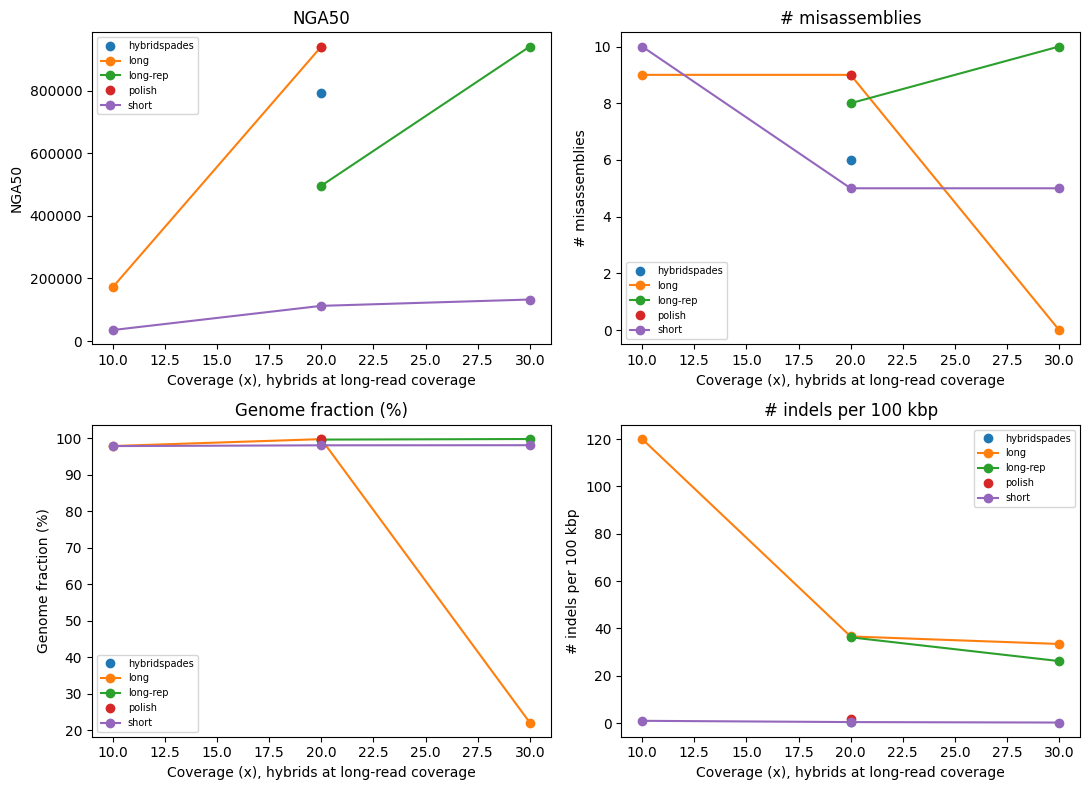

In [ ]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

def list_assemblies():
    pats = ['asm/short_*x/contigs.fasta', 'asm/long_*x*/assembly.fasta',
            'asm/hybridspades_*/contigs.fasta', 'asm/polish_*/polished.fasta']
    out = []
    for pat in pats:
        for p in sorted(glob.glob(pat)):
            if os.path.getsize(p) > 0:
                out.append((Path(p).parent.name, p))
    return out

cands = list_assemblies()
print('assemblies:', [l for l, _ in cands])
sh('rm -rf results/quast')
sh(f'quast.py -r {REF} -t {T} --min-contig 500 --no-icarus -o results/quast '
   + ' '.join(p for _, p in cands) + ' --labels ' + ','.join(l for l, _ in cands), 'quast2', check=True)

def parse_label(label):
    m = re.match(r'(short|long)_(\d+)x(-rep\d+)?$', label)
    if m:
        return m.group(1) + ('-rep' if m.group(3) else ''), int(m.group(2))
    m = re.match(r'(hybridspades|polish)_s(\d+)_l(\d+)$', label)
    return m.group(1), int(m.group(3))     # hybrids are plotted at their long-read coverage

q = pd.read_csv('results/quast/transposed_report.tsv', sep='\t').rename(columns={'Assembly': 'label'})
q['strategy'] = q['label'].apply(lambda s: parse_label(s)[0])
q['cov'] = q['label'].apply(lambda s: parse_label(s)[1])
cols = ['label', '# contigs', 'Total length', 'Largest contig', 'N50', 'NGA50', '# misassemblies',
        'Genome fraction (%)', 'Duplication ratio', '# mismatches per 100 kbp', '# indels per 100 kbp']
cols = [c for c in cols if c in q.columns]
q[cols].to_csv('results/assembly_summary_v2.csv', index=False)
print(q[cols].to_string(index=False))

metrics = [m for m in ['NGA50', '# misassemblies', 'Genome fraction (%)', '# indels per 100 kbp'] if m in q.columns]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, m in zip(axes.ravel(), metrics):
    for s, g in q.groupby('strategy'):
        g = g.sort_values('cov')
        ax.plot(g['cov'], pd.to_numeric(g[m], errors='coerce'), 'o-' if len(g) > 1 else 'o', label=s)
    ax.set_xlabel('Coverage (x), hybrids at long-read coverage'); ax.set_ylabel(m); ax.set_title(m); ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig('results/figures/assembly_metrics_v2.png', dpi=200)
plt.show()
persist()

## 9. Какие участки генома каждая сборка не покрыла (повторы, rRNA, IS-элементы, GC)

In [ ]:
GFF_URL = REF_URL.replace('_genomic.fna.gz', '_genomic.gff.gz')
GFF = str(REFD/'ref.gff')
if not Path(GFF).exists():
    sh(f'wget -q -O {REFD}/ref.gff.gz {GFF_URL} && gunzip -c {REFD}/ref.gff.gz > {GFF}', 'download_gff')

def read_fasta(p):
    seq = []
    for l in open(p):
        if l.startswith('>'):
            if seq:
                break
            continue
        seq.append(l.strip().upper())
    return ''.join(seq)

REFSEQ = read_fasta(REF)
FEAT = {'rRNA': [], 'tRNA': [], 'mobile_genetic_element': [], 'repeat_region': []}
for l in open(GFF):
    if l.startswith('#'):
        continue
    c = l.rstrip('\n').split('\t')
    if len(c) >= 9 and c[2] in FEAT:
        FEAT[c[2]].append((int(c[3]) - 1, int(c[4])))
print('features in GFF:', {k: len(v) for k, v in FEAT.items()})

def gc(s):
    return (s.count('G') + s.count('C')) / max(1, len(s))

def ov(a, b):
    return max(0, min(a[1], b[1]) - max(a[0], b[0]))

def uncovered(fasta, label, min_len=100):
    paf = f'results/{label}.paf'
    if not Path(paf).exists():
        sh(f'minimap2 -x asm10 -t {T} {REF} {fasta} > {paf}', f'paf_{label}', check=False)
    iv = sorted((int(c[7]), int(c[8])) for c in (l.split('\t') for l in open(paf) if l.strip()))
    merged = []
    for s, e in iv:
        if merged and s <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    gaps, prev = [], 0
    for s, e in merged:
        if s - prev >= min_len:
            gaps.append((prev, s))
        prev = max(prev, e)
    if len(REFSEQ) - prev >= min_len:
        gaps.append((prev, len(REFSEQ)))
    return gaps

rows = []
for lab, fa in list_assemblies():
    gaps = uncovered(fa, lab)
    tot = sum(e - s for s, e in gaps)
    row = {'assembly': lab, 'n_gaps': len(gaps), 'missing_bp': tot, 'missing_pct': round(100 * tot / len(REFSEQ), 2)}
    for k, fl in FEAT.items():
        row[f'bp_in_{k}'] = sum(ov(g, f) for g in gaps for f in fl)
    row['GC_missing'] = round(gc(''.join(REFSEQ[s:e] for s, e in gaps)), 3) if gaps else None
    rows.append(row)
miss = pd.DataFrame(rows)
miss.to_csv('results/missing_regions.csv', index=False)
print(f'genome GC = {gc(REFSEQ):.3f}')
print(miss.to_string(index=False))
persist()

features in GFF: {'rRNA': 22, 'tRNA': 86, 'mobile_genetic_element': 50, 'repeat_region': 0}
genome GC = 0.508
            assembly  n_gaps  missing_bp  missing_pct  bp_in_rRNA  bp_in_tRNA  bp_in_mobile_genetic_element  bp_in_repeat_region  GC_missing
           short_10x      53       34789         0.75         108          41                          3117                    0       0.529
           short_20x      18       19391         0.42         136          60                          3418                    0       0.509
           short_30x      17       19652         0.42         136          60                          3146                    0       0.512
            long_10x      40       95079         2.05           0         242                         11199                    0       0.475
      long_20x-rep43       7       13195         0.28           0           0                          2589                    0       0.466
            long_20x       3        7896    

## 10. Ошибки по контексту: indel в гомополимерах (исправленная версия: читает VCF от paftools)

In [ ]:
def run_len(seq, pos, base):
    i = pos
    while i > 0 and seq[i - 1] == base:
        i -= 1
    j = pos
    while j < len(seq) and seq[j] == base:
        j += 1
    return j - i

def ctx(st, b):
    best = 1
    for p in (st - 1, st):
        if 0 <= p < len(REFSEQ) and REFSEQ[p] == b:
            best = max(best, run_len(REFSEQ, p, b))
    return best

# baseline: fraction of reference positions inside homopolymers of length >= 4
pos_hp4, i = 0, 0
while i < len(REFSEQ):
    j = i
    while j < len(REFSEQ) and REFSEQ[j] == REFSEQ[i]:
        j += 1
    if j - i >= 4:
        pos_hp4 += j - i
    i = j
base_hp4 = 100 * pos_hp4 / len(REFSEQ)

amap = dict(list_assemblies())
# long_30x (seed 42) is a failed run (duplicated contigs), so its replicate is used instead
targets = [l for l in ['short_30x', 'long_20x', 'long_30x-rep43', 'polish_s30_l20', 'hybridspades_s30_l20'] if l in amap]
rows = []
for lab in targets:
    calls = f'results/{lab}.calls.vcf'
    sh(f'minimap2 -cx asm10 --cs -t {T} {REF} {amap[lab]} | sort -k6,6 -k8,8n | paftools.js call -l 1000 -L 1000 -f {REF} - > {calls}',
       f'calls_{lab}', check=False)
    snp = ins = dele = hp4 = 0
    bins = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0}
    for l in open(calls):
        if l.startswith('#'):
            continue
        c = l.rstrip('\n').split('\t')
        try:
            pos, r, a = int(c[1]), c[3], c[4]
        except Exception:
            continue
        if a.startswith('<') or ',' in a:
            continue
        if len(r) == len(a):
            snp += 1
            continue
        if len(a) > len(r):
            ins += 1
            b = a[1]
        else:
            dele += 1
            b = r[1]
        h = ctx(pos, b)
        bins[min(h, 6)] += 1
        if h >= 4:
            hp4 += 1
    n = ins + dele
    rows.append({'assembly': lab, 'snps': snp, 'insertions': ins, 'deletions': dele,
                 'indels_in_hp>=4_pct': round(100 * hp4 / n, 1) if n else None,
                 'baseline_ref_pos_in_hp>=4_pct': round(base_hp4, 1),
                 'hp1': bins[1], 'hp2': bins[2], 'hp3': bins[3], 'hp4': bins[4], 'hp5': bins[5], 'hp6plus': bins[6]})
hp_df = pd.DataFrame(rows)
hp_df.to_csv('results/indel_context.csv', index=False)
print(hp_df.to_string(index=False))
persist()

[calls_short_30x] started...
0 [3,50) deletions
0 [3,50) insertions
6 [50,1000) deletions
0 [50,1000) insertions
1 >=1000 deletions
0 >=1000 insertions
[calls_short_30x] exit=0 time=3s
[calls_long_20x] started...
8 [3,50) deletions
3 [3,50) insertions
1 [50,1000) deletions
2 [50,1000) insertions
0 >=1000 deletions
2 >=1000 insertions
[calls_long_20x] exit=0 time=3s
[calls_long_30x-rep43] started...
4 [3,50) deletions
0 [3,50) insertions
1 [50,1000) deletions
2 [50,1000) insertions
0 >=1000 deletions
2 >=1000 insertions
[calls_long_30x-rep43] exit=0 time=2s
[calls_polish_s30_l20] started...
1 [3,50) deletions
2 [3,50) insertions
1 [50,1000) deletions
2 [50,1000) insertions
0 >=1000 deletions
2 >=1000 insertions
[calls_polish_s30_l20] exit=0 time=2s
[calls_hybridspades_s30_l20] started...
0 [3,50) deletions
0 [3,50) insertions
3 [50,1000) deletions
0 [50,1000) insertions
1 >=1000 deletions
0 >=1000 insertions
[calls_hybridspades_s30_l20] exit=0 time=2s
            assembly  snps  inserti

## 11. Модель стоимости (заполни цены сама, со ссылкой на источник)
Цены за гигабазу зависят от платформы и центра. **Не оставляй придуманных чисел:** возьми значения из публикации или прайса и укажи источник в отчёте.

In [ ]:
PRICE_PER_GB = {'short': None, 'long': None}     # USD per Gb. FILL IN with cited prices, e.g. 8.0 and 25.0
PRICE_SOURCE = 'TODO: cite source'

def gb_used(label):
    m = re.match(r'(short|long)_(\d+)x', label)
    if m:
        return {m.group(1): int(m.group(2)) * GS / 1e9}
    m = re.match(r'(hybridspades|polish)_s(\d+)_l(\d+)', label)
    return {'short': int(m.group(2)) * GS / 1e9, 'long': int(m.group(3)) * GS / 1e9}

if all(v is not None for v in PRICE_PER_GB.values()):
    qq = pd.read_csv('results/assembly_summary_v2.csv')
    qq['cost_usd'] = qq['label'].apply(lambda l: sum(PRICE_PER_GB[k] * v for k, v in gb_used(l).items()))
    qq[['label', 'cost_usd', 'NGA50', '# misassemblies', 'Genome fraction (%)']].to_csv('results/cost_vs_quality.csv', index=False)
    print('prices source:', PRICE_SOURCE)
    print(qq[['label', 'cost_usd', 'NGA50', '# misassemblies', 'Genome fraction (%)']].to_string(index=False))
else:
    print('Fill PRICE_PER_GB in this cell, then re-run it (takes a second).')

Fill PRICE_PER_GB in this cell, then re-run it (takes a second).


## 12. Итог и архив для отправки

In [ ]:
persist()
parts = []
for f in ['results/long_diagnostics.txt', 'results/assembly_summary_v2.csv', 'results/missing_regions.csv',
          'results/indel_context.csv', 'results/cost_vs_quality.csv']:
    if Path(f).exists():
        parts.append(f'===== {f} =====\n' + Path(f).read_text())
summary = '\n'.join(parts)
Path('RESULTS_SUMMARY_PART2.txt').write_text(summary)
print(summary)

import zipfile
with zipfile.ZipFile('results_bundle_part2.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for root in ['results', 'logs']:
        for p in Path(root).rglob('*'):
            if p.is_file() and p.suffix not in ('.bam', '.bai', '.paf') and p.stat().st_size < 20_000_000:
                z.write(p)
    z.write('RESULTS_SUMMARY_PART2.txt')
shutil.copy('results_bundle_part2.zip', DRIVE/'results_bundle_part2.zip')
from google.colab import files
files.download('results_bundle_part2.zip')

===== results/long_diagnostics.txt =====
===== long_20x: assembly_info.txt =====
#seq_name	length	cov.	circ.	repeat	mult.	alt_group	graph_path
contig_3	2058693	22	N	N	1	*	*,3,*
contig_1	1535391	20	N	N	1	*	*,1
contig_2	559667	17	N	N	1	*	*,2,*
contig_5	290177	19	N	N	1	*	*,5,*
contig_4	197717	15	N	N	1	*	4
contig_6	85303	21	Y	N	1	*	6

----- long_20x: contig vs reference (minimap2 asm10) -----
contig_1: len=1535391 aligned_query_bases=1535321 n_alignments=2 aligned/len=1.00
contig_2: len=559667 aligned_query_bases=556267 n_alignments=2 aligned/len=0.99
contig_3: len=2058693 aligned_query_bases=2058682 n_alignments=1 aligned/len=1.00
contig_4: len=197717 aligned_query_bases=197697 n_alignments=1 aligned/len=1.00
contig_5: len=290177 aligned_query_bases=290136 n_alignments=1 aligned/len=1.00
contig_6: len=85303 aligned_query_bases=5124 n_alignments=7 aligned/len=0.06
===== long_30x: assembly_info.txt =====
#seq_name	length	cov.	circ.	repeat	mult.	alt_group	graph_path
contig_2	3274133	32	N	N	1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>